In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import os

In [2]:
path = 'D:/SSCode/DST/EDW/'

if os.path.exists(path + 'olist_orders_dataset.csv'):
    orders = pd.read_csv(path + 'olist_orders_dataset.csv')
    reviews = pd.read_csv(path + 'olist_order_reviews_dataset.csv')
    customers = pd.read_csv(path + 'olist_customers_dataset.csv')
    items = pd.read_csv(path + 'olist_order_items_dataset.csv')
    products = pd.read_csv(path + 'olist_products_dataset.csv')
    translation = pd.read_csv(path + 'product_category_name_translation.csv')
    geo = pd.read_csv(path + 'olist_geolocation_dataset.csv')
    print
else:
    print

In [3]:
# 1.Preprocessing (Logic: Late vs On-Time)
# -----------------------------------------------------------------------------
# 날짜 변환
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# 핵심 변수: 지연 여부(is_late) & 지연 일수(delay_days)
orders['is_late'] = (orders['order_delivered_customer_date'] > orders['order_estimated_delivery_date']).astype(int)
orders['delay_days'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days

# 데이터 병합 (Final DF)
final_df = pd.merge(orders, reviews[['order_id', 'review_score']], on='order_id', how='inner')
final_df = pd.merge(final_df, customers[['customer_id', 'customer_zip_code_prefix']], on='customer_id', how='inner')
final_df = pd.merge(final_df, items[['order_id', 'product_id']], on='order_id', how='left')

# 카테고리 영문명
products_merged = pd.merge(products, translation, on='product_category_name', how='left')
final_df = pd.merge(final_df, products_merged[['product_id', 'product_category_name_english']], on='product_id', how='left')

In [4]:
# 2. Visualization: The "Red vs Blue" Map
# -----------------------------------------------------------------------------
# 좌표 최적화
geo_coords = geo.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

final_df = pd.merge(final_df, geo_coords, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='inner')

# 컬럼명 자동 매칭 (Error Proof)
lat_col = 'geolocation_lat' if 'geolocation_lat' in final_df.columns else 'geolocation_lat_y'
lng_col = 'geolocation_lng' if 'geolocation_lng' in final_df.columns else 'geolocation_lng_y'

# ★ 핵심 로직: 리스크 분리
# Red: 배송이 늦어서 화남 (물류 문제 -> 마케팅 금지 구역)
logistics_fail = final_df[(final_df['is_late'] == 1) & (final_df['review_score'] <= 2)]
# Blue: 배송은 왔는데 화남 (상품 문제 -> 고품질 전략 진입 구역)
quality_fail = final_df[(final_df['is_late'] == 0) & (final_df['review_score'] <= 2)]

# 지도 생성
m = folium.Map(location=[-14.235, -51.925], zoom_start=4, tiles='cartodbpositron')

fg_red = folium.FeatureGroup(name='Logistics Risk (Red)').add_to(m)
fg_blue = folium.FeatureGroup(name='Quality Risk (Blue)').add_to(m)

# 점 찍기 (속도를 위해 1000개 샘플링)
if len(logistics_fail) > 0:
    for lat, lng in zip(logistics_fail[lat_col][:1000], logistics_fail[lng_col][:1000]):
        folium.CircleMarker([lat, lng], radius=2, color='red', fill=True, fill_opacity=0.6).add_to(fg_red)

if len(quality_fail) > 0:
    for lat, lng in zip(quality_fail[lat_col][:1000], quality_fail[lng_col][:1000]):
        folium.CircleMarker([lat, lng], radius=2, color='blue', fill=True, fill_opacity=0.6).add_to(fg_blue)

folium.LayerControl().add_to(m)
m.save('final_risk_map.html')
print(f"🗺️ [결과 1] 전략 지도 저장 완료: {os.getcwd()}\\final_risk_map.html")

🗺️ [결과 1] 전략 지도 저장 완료: D:\SSCode\DST\EDW\final_risk_map.html


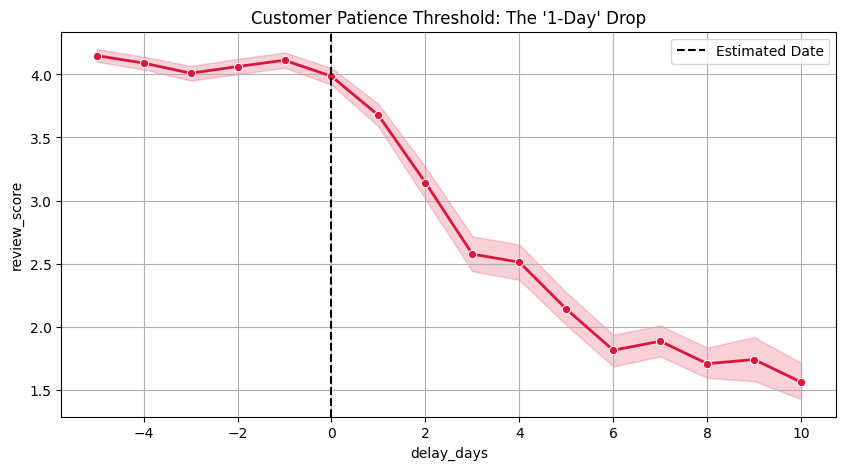

📈 [결과 2] 임계점 그래프 출력 완료


In [5]:
# 3. Insight: Threshold Graph (1-Day Delay Rule)
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 5))
delay_data = final_df[(final_df['delay_days'] >= -5) & (final_df['delay_days'] <= 10)]
sns.lineplot(data=delay_data, x='delay_days', y='review_score', marker='o', color='crimson', linewidth=2)
plt.axvline(0, color='black', linestyle='--', label='Estimated Date')
plt.title("Customer Patience Threshold: The '1-Day' Drop")
plt.grid(True)
plt.legend()
plt.show()
print("📈 [결과 2] 임계점 그래프 출력 완료")

In [6]:
# 4. Strategy: Target Categories (Where to Sell)
# -----------------------------------------------------------------------------
# 파란 점(품질 문제)이 가장 많은 카테고리 추출
cat_group = quality_fail.groupby('product_category_name_english')['order_id'].count().reset_index()
cat_group.columns = ['Category', 'Quality_Fail_Count']
cat_total = final_df.groupby('product_category_name_english')['order_id'].count().reset_index()
cat_summary = pd.merge(cat_group, cat_total, left_on='Category', right_on='product_category_name_english')
cat_summary['Fail_Rate'] = (cat_summary['Quality_Fail_Count'] / cat_summary['order_id']) * 100

print("\n🏆 [결과 3] '품질 전략'으로 진입해야 할 TOP 5 카테고리 (주문 500건 이상):")
display(cat_summary[cat_summary['order_id'] >= 500].sort_values('Fail_Rate', ascending=False).head(5)[['Category', 'Fail_Rate', 'Quality_Fail_Count']])


🏆 [결과 3] '품질 전략'으로 진입해야 할 TOP 5 카테고리 (주문 500건 이상):


,Category,Fail_Rate,Quality_Fail_Count
56,office_furniture,21.177870,356
38,furniture_decor,15.108866,1256
14,computers_accessories,14.477555,1132
7,bed_bath_table,14.375731,1597
47,home_construction,13.833333,83
